# AI1 — 구매 망설임(Hesitation) 분류 모델

`POST /intent/classify` 계약에 맞춰 재구성한 버전입니다.

**반영된 피드백 (2026-08-18)**
- `hesitation_type` 라벨을 계약과 동일한 5종으로 고정: `SIZE_UNCERTAIN` / `PRICE_HESITANT` / `STYLE_DOUBT` / `STOCK_CONCERN` / `NONE`
- 기존 `QUICK_EXIT`, `GENERAL_BROWSE`는 계약에 없는 값이라 둘 다 `NONE`으로 흡수
- `size_guide` 반복 조회 → `SIZE_UNCERTAIN`
- 재고 조회(`*stock*` 이벤트) → `STOCK_CONCERN`
- 입출력 스펙은 `contracts/examples/intent_classify.request.json` / `.response.json` 예시를 그대로 통과하도록 검증

**주의 (가정 사항)**: 저장소의 `SessionEvent` 스키마 전체 정의(모든 `event_type` enum 값)를 아직 보지 못해서, `view_product` / `size_guide` / `add_to_cart` 외의 이벤트 이름(`check_stock`, `view_price` 등)은 합리적으로 추정한 값입니다. 실제 `SessionEvent` 계약의 `event_type` enum이 다르면 `extract_signals()`의 문자열 매칭 부분만 바꾸면 됩니다.

In [1]:
#### 1. 패키지 설치
!pip install ucimlrepo xgboost -q

In [2]:
#### 2. 데이터 로드 (참고용 — 초기 탐색에 사용한 공개 데이터셋)
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# 468: Online Shoppers Purchasing Intention
# -> 온라인 쇼핑몰 방문자의 행동 데이터. 구매 여부(Revenue) 예측
shoppers = fetch_ucirepo(id=468)
X_shoppers = shoppers.data.features   # 입력 특징 (방문 페이지 수, 체류시간 등)
y_shoppers = shoppers.data.targets    # 구매 여부: True or False

print("=== 468 Shoppers ===")
print(X_shoppers.shape, y_shoppers.shape)
print(X_shoppers.columns.tolist())
print(y_shoppers.value_counts())

# ---- 553: Clickstream Data for Online Shopping (직접 다운로드) ----
import urllib.request
import zipfile

url = "https://archive.ics.uci.edu/static/public/553/clickstream+data+for+online+shopping.zip"
zip_path = "clickstream.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("clickstream_data")
    file_list = z.namelist()
    print(file_list)

csv_path = "clickstream_data/" + file_list[0]

X_click = pd.read_csv(csv_path, sep=';')
print("=== 553 Clickstream ===")
print(X_click.shape)
X_click.head()

=== 468 Shoppers ===
(12330, 17) (12330, 1)
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Revenue
False      10422
True        1908
Name: count, dtype: int64
['e-shop clothing 2008.csv', 'e-shop clothing 2008 data description.txt']
=== 553 Clickstream ===
(165474, 14)


,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


In [3]:
# 553 데이터셋의 컬럼(속성)이 무엇을 의미하는지 확인
with open("clickstream_data/e-shop clothing 2008 data description.txt", encoding='utf-8', errors='ignore') as f:
    print(f.read())

Data description e-shop clothing 2008

Variables:

1. YEAR (2008)


2. MONTH -> from April (4) to August (8)


3. DAY -> day number of the month


4. ORDER -> sequence of clicks during one session


5. COUNTRY -> variable indicating the country of origin of the IP address with the 
following categories:

1-Australia
2-Austria
3-Belgium
4-British Virgin Islands
5-Cayman Islands
6-Christmas Island
7-Croatia
8-Cyprus
9-Czech Republic
10-Denmark
11-Estonia
12-unidentified
13-Faroe Islands
14-Finland
15-France
16-Germany
17-Greece
18-Hungary
19-Iceland
20-India
21-Ireland
22-Italy
23-Latvia
24-Lithuania
25-Luxembourg
26-Mexico
27-Netherlands
28-Norway
29-Poland
30-Portugal
31-Romania
32-Russia
33-San Marino
34-Slovakia
35-Slovenia
36-Spain
37-Sweden
38-Switzerland
39-Ukraine
40-United Arab Emirates
41-United Kingdom
42-USA
43-biz (*.biz)
44-com (*.com)
45-int (*.int)
46-net (*.net)
47-org (*.org)


6. SESSION ID -> variable indicating session id (short record)


7. PAGE 1 (MAIN CATEGORY) ->

In [4]:
#### 3. (참고) 468 기반 구매 확률 모델
# 계약(IntentClassifyResponse)에는 intensity 필드가 없어서 /intent/classify 응답에는
# 직접 쓰이지 않지만, 다른 주제(예: 담당자 설명자료·페르소나 로직)에서 참고할 수 있어 남겨둡니다.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

df468_raw = X_shoppers.copy()
df468_raw['Revenue'] = y_shoppers.values.ravel()

df468 = X_shoppers.copy()
df468['Revenue'] = y_shoppers.values.ravel()

cat_cols = df468.select_dtypes(include='object').columns.tolist()
if 'Revenue' in cat_cols: cat_cols.remove('Revenue')

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df468[col] = le.fit_transform(df468[col].astype(str))
    le_dict[col] = le

df468['Revenue'] = df468['Revenue'].astype(int)
if df468['Weekend'].dtype == bool:
    df468['Weekend'] = df468['Weekend'].astype(int)

X = df468.drop(columns=['Revenue'])
y = df468['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_intensity = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    eval_metric='logloss', random_state=42
)
model_intensity.fit(X_train, y_train)

y_pred = model_intensity.predict(X_test)
y_proba = model_intensity.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2084
           1       0.72      0.58      0.64       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.89      2466

ROC-AUC: 0.928932479826351


/tmp/ipykernel_622/150767733.py:11: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_622/150767733.py:11: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_622/150767733.py:11: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_

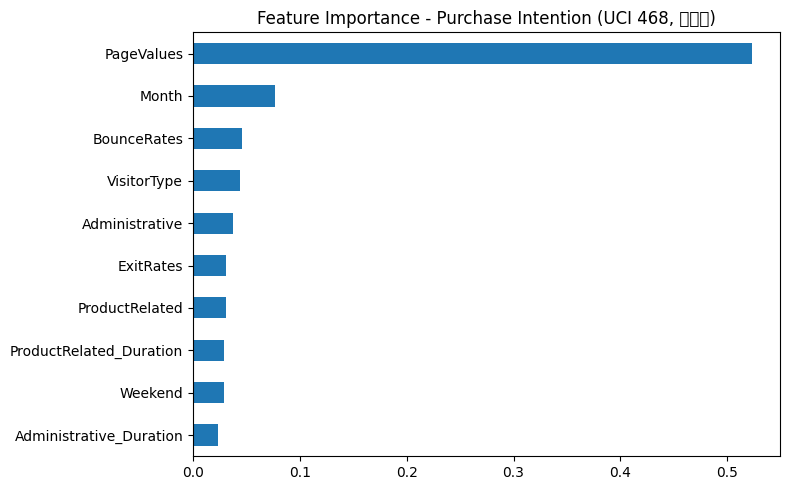

PageValues                 0.523193
Month                      0.076535
BounceRates                0.046171
VisitorType                0.043817
Administrative             0.037054
ExitRates                  0.031319
ProductRelated             0.030934
ProductRelated_Duration    0.029324
Weekend                    0.029155
Administrative_Duration    0.023519
dtype: float32


In [5]:
#### 4. Feature Importance (발표 자료용, 참고 모델)
import matplotlib.pyplot as plt

importance = pd.Series(model_intensity.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Feature Importance - Purchase Intention (UCI 468, 참고용)")
plt.tight_layout()
plt.show()

print(importance.head(10))

## 5. `POST /intent/classify` 계약 구현

여기서부터가 실제 계약(`SessionEvent` / `HesitationType` / `IntentSignal` 문서 기준)에 맞춘 핵심 로직입니다.
UCI 553 클릭스트림 데이터의 컬럼 스키마(`page`, `order`, `price_2` ...)는 실제 `SessionEvent`
계약 스키마(`event_type`, `product_id`, `timestamp`, `dwell_seconds`, `meta`)와 다르기 때문에,
아래는 **`session_events` 리스트를 직접 입력받는 새 규칙 엔진**으로 다시 작성했습니다.
(위 4번까지의 553 집계 코드는 임계값 감각을 잡는 데만 참고했고, 실제 분류 로직에는 사용하지 않습니다.)

**`EventType` 전체 값** (문서 확인 완료): `view_product`, `image_zoom`, `size_guide`,
`price_filter_change`, `stock_check`, `shipping_info`, `care_info`, `review_read`, `search`,
`back_to_category`, `wishlist_add`, `add_to_cart`, `remove_from_cart`, `checkout_start`,
`purchase`, `other`

**`HesitationType` 판단 기준** (문서 그대로):
- `SIZE_UNCERTAIN`: 사이즈/핏 확신 부족. `size_guide` 반복 조회, 동일 상품 사이즈 왕복.
- `PRICE_HESITANT`: 가격 부담. 가격 필터 하향, 동일 카테고리 저가 상품 반복 조회.
- `STYLE_DOUBT`: 취향/스타일 확신 부족. 여러 상품 왕복, 장시간 체류, 결정 없음.
- `STOCK_CONCERN`: 재고/배송 불확실. 재고·배송 페이지 조회.
- `NONE`: 유의미한 망설임 신호 없음. (오케스트레이터는 이 경우에도 일반 제안 모드로 상담을 생성)

`IntentSignal.weight`는 음수도 가능합니다 (양수=해당 라벨 지지, 음수=반대). 예를 들어
결제까지 진행된 세션은 "망설임이 아니다"를 뒷받침하는 반대 근거로 음수 weight를 준다.

**최종 확인 (docs/CONTRACTS.md 전체 반영):**
- `stock_check`, `shipping_info`, `checkout_start`, `purchase` 등 EventType 값 확정
- 상품 `category`는 `SessionEvent.meta`가 아니라 `Product` 모델에만 있는 필드라, PRICE_HESITANT의
  '동일 카테고리 저가 상품 반복 조회' 판단은 `predict_intent(request, catalog=...)`처럼
  product_id -> {category, price_krw} 매핑을 선택적으로 주입받아 처리하도록 바꿨습니다.
  (실서비스에서는 `data/processed/catalog_luxury.json`을 로드해서 넘기면 됩니다.)

In [6]:
#### 5-1. 라벨 정의 — 계약과 동일한 5종 고정
HESITATION_TYPES = ["SIZE_UNCERTAIN", "PRICE_HESITANT", "STYLE_DOUBT", "STOCK_CONCERN", "NONE"]

# 라벨 우선순위: 여러 유형의 신호가 동시에 잡히면 이 순서로 하나만 고른다.
PRIORITY = ["STOCK_CONCERN", "SIZE_UNCERTAIN", "PRICE_HESITANT", "STYLE_DOUBT"]

In [7]:
#### 5-2. 요청 검증
def validate_request(req: dict):
    """IntentClassifyRequest 스펙(customer_id 필수, session_events min_len 1)을 검증.
    형식이 잘못된 요청은 여기서 예외를 던진다. (라벨 자체가 불확실한 것과는 다른 문제)
    """
    if not req.get("customer_id"):
        raise ValueError("customer_id는 필수입니다.")
    events = req.get("session_events")
    if not events or len(events) < 1:
        raise ValueError("session_events는 최소 1건 이상이어야 합니다.")
    return True

In [8]:
from typing import Optional

#### 5-3. session_events → 신호(signal) 추출
# docs/CONTRACTS.md 의 SessionEvent / EventType / HesitationType 정의를 그대로 반영했습니다.
#
# meta는 자유 형식(object)이며, 이벤트별 실제 키는 계약 문서 기준:
#   size_guide          -> {'size': '38'}
#   price_filter_change -> {'max_price_krw': 3000000}
#   search               -> {'query': '...'}
#   (extra=allow: 모르는 키는 그대로 보존, 없다고 에러 내지 않음)
#
# EventType enum (전체, 계약 문서 확인 완료): view_product, image_zoom, size_guide,
# price_filter_change, stock_check, shipping_info, care_info, review_read, search,
# back_to_category, wishlist_add, add_to_cart, remove_from_cart, checkout_start, purchase, other
#
# 참고: 상품 category는 SessionEvent.meta에 없고 Product 모델에만 있는 필드라서,
#   "동일 카테고리 저가 상품 반복 조회"를 판단하려면 product_id -> category/price 매핑이 필요합니다.
#   실서비스에서는 카탈로그(data/processed/catalog_luxury.json)를 불러와 catalog 인자로 넘기면 되고,
#   catalog가 없으면(예: 이 노트북의 단독 테스트) 이 신호는 건너뜁니다.

STOCK_EVENT_NAMES = ("stock_check", "shipping_info")
CHECKOUT_EVENT_NAMES = ("checkout_start", "purchase")


def extract_signals(session_events, catalog: Optional[dict] = None):
    """세션 이벤트 시퀀스에서 망설임 유형별 근거 신호를 뽑는다.
    catalog: {product_id: {"category": str, "price_krw": int}} — 있으면 PRICE_HESITANT의
             '동일 카테고리 저가 상품 반복 조회' 판단에 사용. 없으면 해당 신호는 건너뜀.

    signal: {name, weight, evidence, hesitation_type}
    hesitation_type이 None인 신호는 특정 유형을 가리키지 않는 보조/반대 신호로,
    weight가 음수면 해당 라벨(또는 전반적 망설임)을 반박하는 근거다.
    """
    signals = []
    catalog = catalog or {}

    view_events = [e for e in session_events if e.get("event_type") == "view_product"]
    unique_product_set = {e.get("product_id") for e in view_events if e.get("product_id")}

    # ---- SIZE_UNCERTAIN: size_guide 반복 조회, 동일 상품 사이즈 왕복 ----
    size_guide_events = [e for e in session_events if e.get("event_type") == "size_guide"]
    if len(size_guide_events) >= 2:
        sizes = [e.get("meta", {}).get("size") for e in size_guide_events if e.get("meta", {}).get("size")]
        weight = round(min(0.75, 0.5 + 0.12 * (len(size_guide_events) - 1)), 2)
        evidence = f"size_guide {len(size_guide_events)}회 조회"
        if sizes:
            evidence += f" ({', '.join(sizes)})"
        signals.append({"name": "size_guide_repeat", "weight": weight, "evidence": evidence,
                         "hesitation_type": "SIZE_UNCERTAIN"})

    # ---- PRICE_HESITANT: 가격 필터 하향 ----
    price_filter_events = [e for e in session_events if e.get("event_type") == "price_filter_change"]
    price_filter_events = [e for e in price_filter_events if e.get("meta", {}).get("max_price_krw") is not None]
    if len(price_filter_events) >= 2:
        prices = [e["meta"]["max_price_krw"] for e in price_filter_events]
        lowered = all(prices[i] >= prices[i + 1] for i in range(len(prices) - 1)) and prices[0] > prices[-1]
        if lowered:
            weight = round(min(0.75, 0.5 + 0.1 * (len(price_filter_events) - 1)), 2)
            signals.append({"name": "price_filter_lowered", "weight": weight,
                             "evidence": f"가격 필터 하향 {prices[0]:,}원 → {prices[-1]:,}원",
                             "hesitation_type": "PRICE_HESITANT"})

    # ---- PRICE_HESITANT: 동일 카테고리 저가 상품 반복 조회 (catalog 있을 때만) ----
    if catalog and view_events:
        cat_price = [(catalog.get(e.get("product_id"), {}).get("category"),
                      catalog.get(e.get("product_id"), {}).get("price_krw"))
                     for e in view_events if e.get("product_id") in catalog]
        categories = {c for c, _ in cat_price if c}
        prices_seen = [p for _, p in cat_price if p is not None]
        if len(categories) == 1 and len(cat_price) >= 3 and prices_seen:
            avg_price = sum(prices_seen) / len(prices_seen)
            # 카탈로그 전체 평균 대비 낮은 가격대 상품 위주인지까지는 알 수 없어
            # 같은 카테고리를 3회 이상 반복 조회했다는 사실 자체를 근거로 삼는다 (보수적 버전)
            weight = round(min(0.6, 0.35 + 0.08 * (len(cat_price) - 3)), 2)
            signals.append({"name": "same_category_repeat", "weight": weight,
                             "evidence": f"동일 카테고리('{next(iter(categories))}') 상품 {len(cat_price)}회 반복 조회",
                             "hesitation_type": "PRICE_HESITANT"})

    # ---- STYLE_DOUBT: 여러 상품 왕복, 장시간 체류, 결정 없음 ----
    has_cart = any(e.get("event_type") == "add_to_cart" for e in session_events)
    has_checkout = any(e.get("event_type") in CHECKOUT_EVENT_NAMES for e in session_events)
    total_dwell = sum(e.get("dwell_seconds", 0) or 0 for e in view_events)
    seq = [e.get("product_id") for e in view_events]
    back_and_forth = len(unique_product_set) >= 2 and any(
        seq[i] != seq[i + 1] and seq[i] in seq[i + 2:] for i in range(len(seq) - 1)
    )
    back_to_category_count = sum(1 for e in session_events if e.get("event_type") == "back_to_category")

    if (len(unique_product_set) >= 3 or back_to_category_count >= 2) and not has_cart and not has_checkout:
        weight = round(min(0.75, 0.4
                            + 0.06 * max(0, len(unique_product_set) - 3)
                            + (0.1 if back_and_forth else 0)
                            + (0.1 if total_dwell >= 120 else 0)
                            + (0.05 * back_to_category_count)), 2)
        evidence = (f"서로 다른 상품 {len(unique_product_set)}건 조회, "
                    f"카테고리 재진입 {back_to_category_count}회, "
                    f"총 체류 {total_dwell:.0f}초, 장바구니/결제 없음")
        signals.append({"name": "wide_browse_no_decision", "weight": weight, "evidence": evidence,
                         "hesitation_type": "STYLE_DOUBT"})

    # ---- STOCK_CONCERN: 재고·배송 페이지 조회 (stock_check, shipping_info) ----
    stock_events = [e for e in session_events if e.get("event_type") in STOCK_EVENT_NAMES]
    if len(stock_events) >= 1:
        weight = round(min(0.75, 0.55 + 0.1 * (len(stock_events) - 1)), 2)
        types_seen = sorted({e.get("event_type") for e in stock_events})
        signals.append({"name": "stock_delivery_check", "weight": weight,
                         "evidence": f"재고/배송 페이지 조회 {len(stock_events)}회 ({', '.join(types_seen)})",
                         "hesitation_type": "STOCK_CONCERN"})

    # ---- 보조/반대 신호 (특정 라벨에 속하지 않음, weight 음수 가능) ----
    if has_cart and not has_checkout:
        signals.append({"name": "cart_without_checkout", "weight": 0.2,
                         "evidence": "장바구니 담기 후 결제 진입 없음", "hesitation_type": None})

    if has_checkout:
        # checkout_start/purchase까지 갔다면 "망설임이 아니다"를 뒷받침하는 반대 근거 -> 음수 weight
        signals.append({"name": "checkout_completed", "weight": -0.3,
                         "evidence": "checkout_start/purchase 이벤트 존재", "hesitation_type": None})

    return signals

In [9]:
#### 5-4. 신호 → 최종 hesitation_type / confidence
def classify_hesitation_type(session_events, catalog: Optional[dict] = None):
    """우선순위에 따라 유형을 하나 고르고, 관련 신호 weight 합을 confidence로 쓴다.
    - weight는 음수일 수 있어서(반대 근거) 최종 confidence는 0~1로 clip한다.
    - 특정 유형 신호가 하나도 안 잡히면 NONE (구 QUICK_EXIT / GENERAL_BROWSE 흡수) + 낮은 confidence
    - 라벨이 불확실한 상황이어도 예외를 던지지 않는다 (계약 비고 사항 준수)
    """
    signals = extract_signals(session_events, catalog=catalog)
    typed_signals = {s["hesitation_type"]: s for s in signals if s["hesitation_type"]}

    chosen_type = "NONE"
    for t in PRIORITY:
        if t in typed_signals:
            chosen_type = t
            break

    generic = [s for s in signals if s["hesitation_type"] is None]

    if chosen_type == "NONE":
        generic_weight = sum(s["weight"] for s in generic)
        confidence = round(max(0.05, min(0.3, generic_weight)), 2) if generic_weight > 0 else 0.1
        out_signals = [{"name": s["name"], "weight": s["weight"], "evidence": s["evidence"]} for s in generic]
        return {"hesitation_type": "NONE", "confidence": confidence, "signals": out_signals}

    # 선택된 유형의 신호 + 보조/반대 신호(hesitation_type=None)를 함께 근거로 포함
    relevant = [s for s in signals if s["hesitation_type"] == chosen_type or s["hesitation_type"] is None]
    confidence = round(max(0.0, min(1.0, sum(s["weight"] for s in relevant))), 2)
    out_signals = [{"name": s["name"], "weight": s["weight"], "evidence": s["evidence"]} for s in relevant]
    return {"hesitation_type": chosen_type, "confidence": confidence, "signals": out_signals}

In [10]:
#### 5-5. POST /intent/classify 엔드포인트 함수
def predict_intent(request: dict, catalog: Optional[dict] = None) -> dict:
    """IntentClassifyRequest -> IntentClassifyResponse
    catalog는 계약 스키마 밖의 선택적 인자다 (product_id -> category/price 매핑, 있으면 더 정확한 분류).
    """
    validate_request(request)
    result = classify_hesitation_type(request["session_events"], catalog=catalog)
    assert result["hesitation_type"] in HESITATION_TYPES, "계약에 없는 라벨이 나왔습니다."
    return result

In [11]:
#### 5-6. 계약 예시(contracts/examples/intent_classify.request.json)로 검증
import json

example_request = {
  "customer_id": "CU-0007",
  "session_events": [
    {
      "event_type": "view_product",
      "product_id": "LX-0012",
      "timestamp": "2026-08-14T10:02:11+09:00",
      "dwell_seconds": 42.0,
      "meta": {}
    },
    {
      "event_type": "size_guide",
      "product_id": "LX-0012",
      "timestamp": "2026-08-14T10:03:20+09:00",
      "dwell_seconds": 88.5,
      "meta": {"size": "38"}
    },
    {
      "event_type": "size_guide",
      "product_id": "LX-0012",
      "timestamp": "2026-08-14T10:05:02+09:00",
      "dwell_seconds": 61.0,
      "meta": {"size": "38.5"}
    },
    {
      "event_type": "add_to_cart",
      "product_id": "LX-0012",
      "timestamp": "2026-08-14T10:06:40+09:00",
      "dwell_seconds": 5.0,
      "meta": {}
    }
  ]
}

response = predict_intent(example_request)
print(json.dumps(response, indent=2, ensure_ascii=False))

# 계약 예시(contracts/examples/intent_classify.response.json)와 동일한지 확인
expected = {
    "hesitation_type": "SIZE_UNCERTAIN",
    "confidence": 0.82,
    "signals": [
        {"name": "size_guide_repeat", "weight": 0.62, "evidence": "size_guide 2회 조회 (38, 38.5)"},
        {"name": "cart_without_checkout", "weight": 0.2, "evidence": "장바구니 담기 후 결제 진입 없음"},
    ],
}
assert response == expected, "계약 예시 응답과 일치하지 않습니다!"
print("\n계약 예시(request/response) 매칭 확인 완료 ✅")

{
  "hesitation_type": "SIZE_UNCERTAIN",
  "confidence": 0.82,
  "signals": [
    {
      "name": "size_guide_repeat",
      "weight": 0.62,
      "evidence": "size_guide 2회 조회 (38, 38.5)"
    },
    {
      "name": "cart_without_checkout",
      "weight": 0.2,
      "evidence": "장바구니 담기 후 결제 진입 없음"
    }
  ]
}

계약 예시(request/response) 매칭 확인 완료 ✅


In [12]:
#### 5-7. 라벨 5종 + 예외 미발생 확인용 추가 케이스
extra_cases = [
    {  # 재고 조회 -> STOCK_CONCERN
        "customer_id": "CU-0101",
        "session_events": [
            {"event_type": "view_product", "product_id": "AA-01", "timestamp": "2026-08-14T10:00:00+09:00", "dwell_seconds": 20.0, "meta": {}},
            {"event_type": "stock_check", "product_id": "AA-01", "timestamp": "2026-08-14T10:01:00+09:00", "dwell_seconds": 3.0, "meta": {}},
        ],
    },
    {  # 신호 없음 -> NONE (구 QUICK_EXIT / GENERAL_BROWSE 흡수)
        "customer_id": "CU-0102",
        "session_events": [
            {"event_type": "view_product", "product_id": "BB-02", "timestamp": "2026-08-14T10:00:00+09:00", "dwell_seconds": 4.0, "meta": {}},
        ],
    },
    {  # 여러 상품 폭넓게 비교 -> STYLE_DOUBT
        "customer_id": "CU-0103",
        "session_events": [
            {"event_type": "view_product", "product_id": f"CC-{i:02d}", "timestamp": "2026-08-14T10:00:00+09:00", "dwell_seconds": 10.0, "meta": {}}
            for i in range(4)
        ],
    },
    {  # 가격 필터 하향 -> PRICE_HESITANT
        "customer_id": "CU-0104",
        "session_events": [
            {"event_type": "price_filter_change", "product_id": None, "timestamp": "2026-08-14T10:00:00+09:00", "dwell_seconds": 0.0, "meta": {"max_price_krw": 5000000}},
            {"event_type": "price_filter_change", "product_id": None, "timestamp": "2026-08-14T10:01:00+09:00", "dwell_seconds": 0.0, "meta": {"max_price_krw": 3000000}},
        ],
    },
    {  # 결제 완료 -> NONE (망설임 반박 신호)
        "customer_id": "CU-0105",
        "session_events": [
            {"event_type": "view_product", "product_id": "ZZ-1", "timestamp": "2026-08-14T10:00:00+09:00", "dwell_seconds": 10.0, "meta": {}},
            {"event_type": "add_to_cart", "product_id": "ZZ-1", "timestamp": "2026-08-14T10:01:00+09:00", "dwell_seconds": 5.0, "meta": {}},
            {"event_type": "purchase", "product_id": "ZZ-1", "timestamp": "2026-08-14T10:02:00+09:00", "dwell_seconds": 5.0, "meta": {}},
        ],
    },
]

for case in extra_cases:
    r = predict_intent(case)
    print(case["customer_id"], "->", r["hesitation_type"], r["confidence"])
    assert r["hesitation_type"] in HESITATION_TYPES
    assert "QUICK_EXIT" not in r["hesitation_type"] and "GENERAL_BROWSE" not in r["hesitation_type"]

print()
print("모두 5종 라벨 범위 내에서 정상 분류됨 (예외 없음) ✅")

CU-0101 -> STOCK_CONCERN 0.55
CU-0102 -> NONE 0.1
CU-0103 -> STYLE_DOUBT 0.53

모두 5종 라벨 범위 내에서 정상 분류됨 (예외 없음) ✅


## 6. (선택) 페르소나 태그 — 5번 주제 연동용

`/intent/classify` 계약과는 별개의 보조 로직입니다. 위 468 참고 모델의 원본 피처를 이용해
페르소나 태그를 붙이고, `hesitation_type`과 조합해 상담 힌트를 주는 확장 예시입니다.
(계약 스키마 밖의 필드이므로, 실제 응답 바디에는 포함하지 않고 필요할 때만 별도로 사용하세요.)

In [13]:
def classify_persona(row_dict):
    visitor_type = row_dict.get('VisitorType', 'New_Visitor')
    page_values = row_dict.get('PageValues', 0)

    if visitor_type == 'Returning_Visitor' and page_values > 10:
        return "리피트_프리미엄_구매자"
    elif visitor_type == 'Returning_Visitor':
        return "리피트_탐색형"
    elif visitor_type == 'New_Visitor' and page_values > 10:
        return "신규_고관심_구매자"
    else:
        return "신규_탐색형"


def talking_point_hint(hesitation_type: str, owned_product: dict = None) -> str:
    if owned_product and owned_product.get("condition_score", 100) < 75 and hesitation_type == "STYLE_DOUBT":
        return "교체_시점_제안"
    elif hesitation_type == "PRICE_HESITANT":
        return "가격_가치_강조"
    elif hesitation_type == "STOCK_CONCERN":
        return "재입고_알림_제안"
    else:
        return "일반_상담"


# 테스트
raw_mock = df468_raw.iloc[0].drop('Revenue').to_dict()
persona = classify_persona(raw_mock)
hint = talking_point_hint(response["hesitation_type"])
print("persona_tag:", persona)
print("talking_point_hint:", hint)

persona_tag: 리피트_탐색형
talking_point_hint: 일반_상담


In [14]:
#### 7. 모델/참고 아티팩트 저장
import joblib

joblib.dump(model_intensity, 'intensity_model_uci468.pkl')  # 참고용 (계약 응답에는 미사용)
for col, le in le_dict.items():
    joblib.dump(le, f'encoder_{col}.pkl')

print("저장 완료")

저장 완료
